# Bank Marketing — End-to-End ML Project

**Goal:** Predict whether a customer will subscribe to a term deposit (`deposit = yes/no`).

Pipeline:
1. Data cleaning
2. EDA
3. Data analysis
4. Preprocessing
5. Multiple classification models
6. Model evaluation
7. GridSearchCV
8. Final tuned model
9. Feature importance


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, balanced_accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
DATA_PATH = "bank.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (8912, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5.0,may,1042.0,1.0,-1.0,0.0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5.0,may,1467.0,1.0,-1.0,0.0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5.0,may,1389.0,1.0,-1.0,0.0,unknown,yes
3,54,admin.,married,tertiary,no,184.0,no,no,unknown,5.0,may,673.0,2.0,-1.0,0.0,unknown,yes
4,42,management,single,tertiary,no,0.0,yes,yes,unknown,5.0,may,562.0,2.0,-1.0,0.0,unknown,yes


## 1. Initial Inspection


In [3]:
print(df.info())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("\nDuplicates:", df.duplicated().sum())
print("\nTarget:")
display(df["deposit"].value_counts(dropna=False).to_frame("count"))
display(df["deposit"].value_counts(normalize=True, dropna=False).mul(100).round(2).to_frame("percentage"))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8912 entries, 0 to 8911
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8912 non-null   int64  
 1   job        8905 non-null   object 
 2   marital    8743 non-null   object 
 3   education  8885 non-null   object 
 4   default    8908 non-null   object 
 5   balance    8899 non-null   float64
 6   housing    8899 non-null   object 
 7   loan       8882 non-null   object 
 8   contact    8881 non-null   object 
 9   day        8893 non-null   float64
 10  month      8884 non-null   object 
 11  duration   8905 non-null   float64
 12  campaign   8904 non-null   float64
 13  pdays      8767 non-null   float64
 14  previous   8909 non-null   float64
 15  poutcome   8912 non-null   object 
 16  deposit    8903 non-null   object 
dtypes: float64(6), int64(1), object(10)
memory usage: 1.2+ MB
None

Missing values:


,missing
marital,169
pdays,145
contact,31
loan,30
month,28
education,27
day,19
balance,13
housing,13
deposit,9



Duplicates: 0

Target:


,count
deposit,
no,4673
yes,4230
NaN,9


,percentage
deposit,
no,52.43
yes,47.46
NaN,0.10


## 2. Data Cleaning

Missing target rows are removed. Feature missing values are handled inside the preprocessing Pipeline to avoid data leakage.


In [4]:
df = df.dropna(subset=["deposit"]).drop_duplicates().reset_index(drop=True)
df["deposit"] = df["deposit"].astype(str).str.strip().str.lower()
df = df[df["deposit"].isin(["yes", "no"])].copy()

print("Clean shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Clean shape: (8903, 17)
Duplicates: 0


,missing
marital,160
pdays,136
contact,31
loan,30
month,28
education,27
day,19
balance,13
housing,13
campaign,8


## 3. Statistical Analysis


In [5]:
display(df.describe(include="all").T)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,8903.0,NaN,NaN,NaN,41.255195,11.841935,18.0,32.0,39.0,49.0,95.0
job,8896,12,management,2077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,8743,3,married,4980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,8876,4,secondary,4359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,8899,2,no,8753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,8890.0,NaN,NaN,NaN,1539.549381,3297.969007,-3058.0,121.25,553.0,1727.0,81204.0
housing,8890,2,no,4651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,8873,2,no,7699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,8872,3,cellular,6381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,8884.0,NaN,NaN,NaN,15.680549,8.409864,1.0,8.0,15.0,22.0,31.0


Numeric: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


## 4. EDA — Target


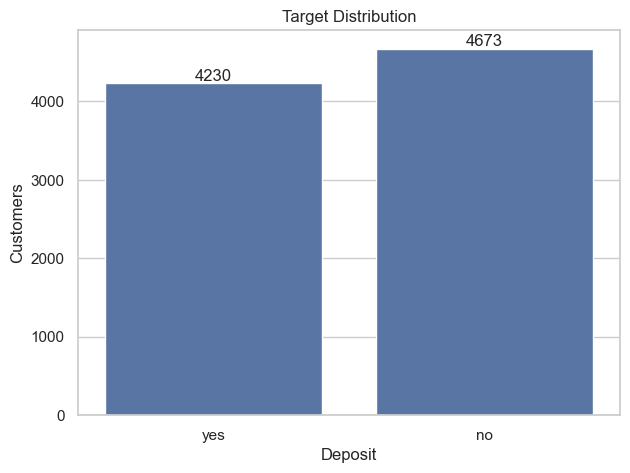

In [6]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x="deposit")
plt.title("Target Distribution")
plt.xlabel("Deposit")
plt.ylabel("Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()


## 5. EDA — Numeric Variables


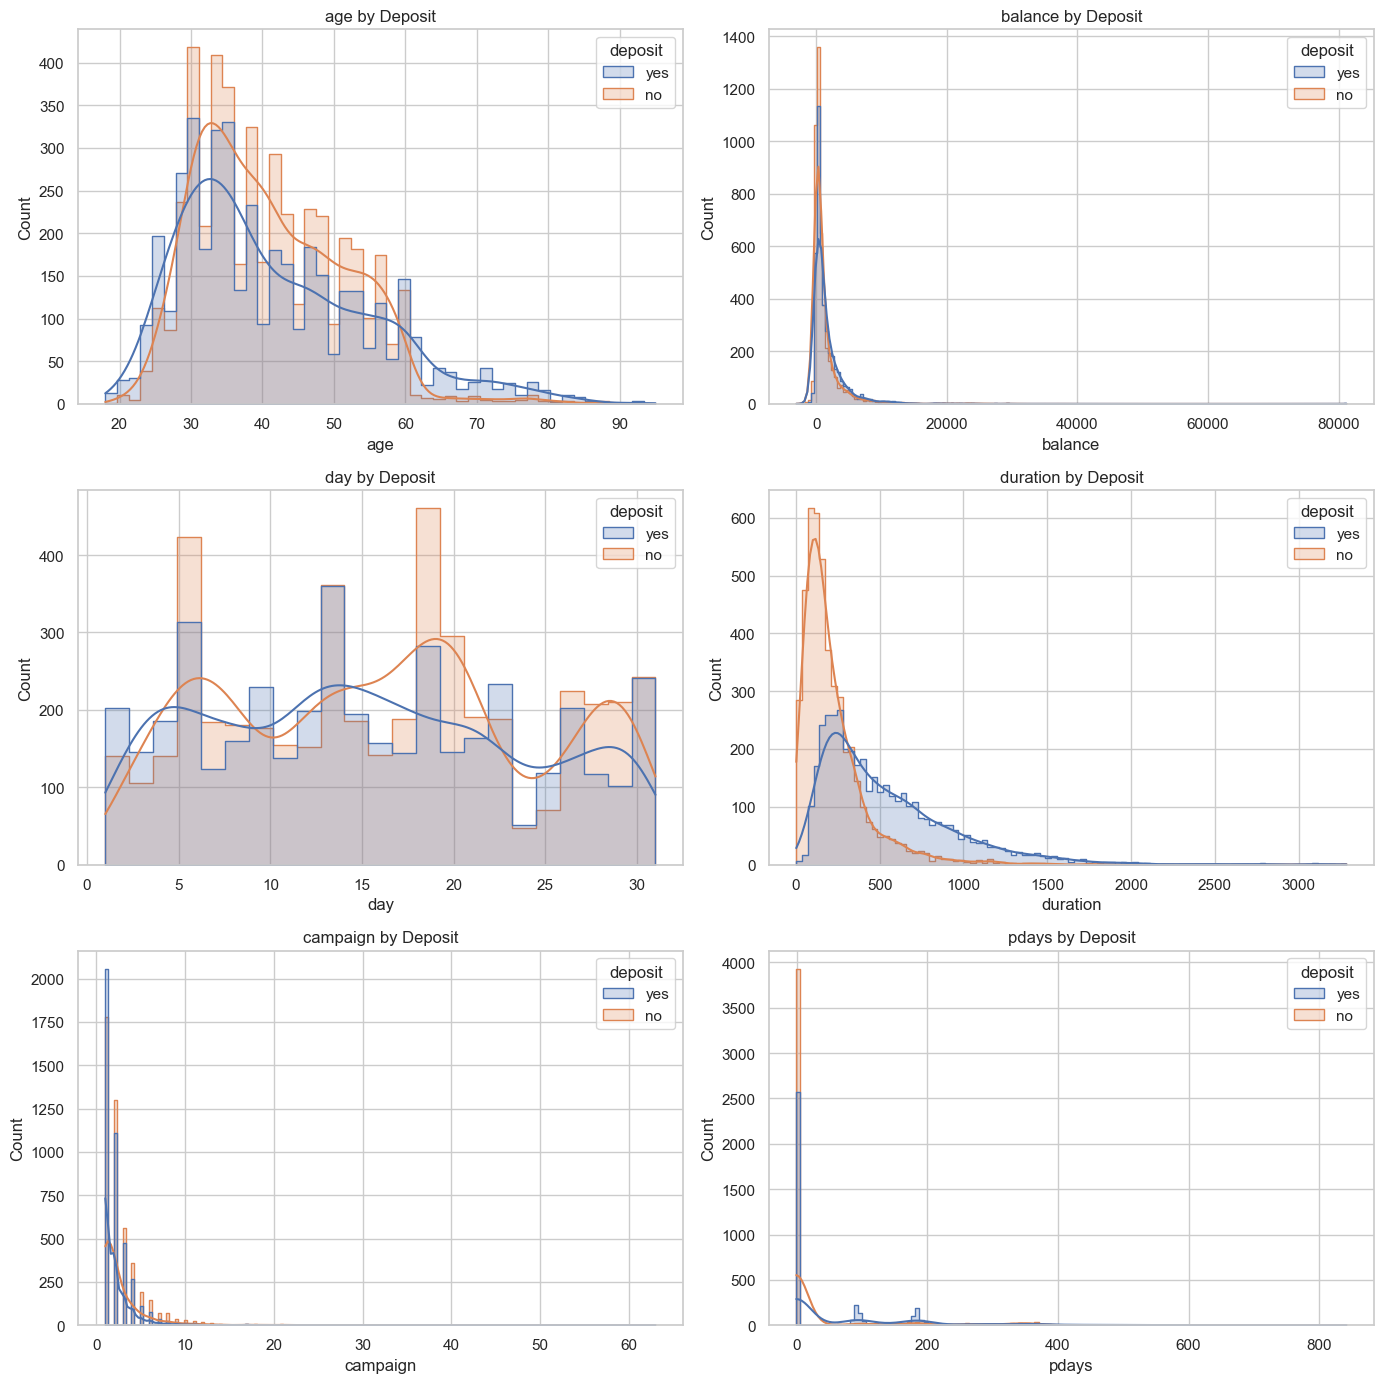

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, hue="deposit", kde=True, element="step", ax=ax)
    ax.set_title(f"{col} by Deposit")
plt.tight_layout()
plt.show()


## 6. EDA — Categorical Variables


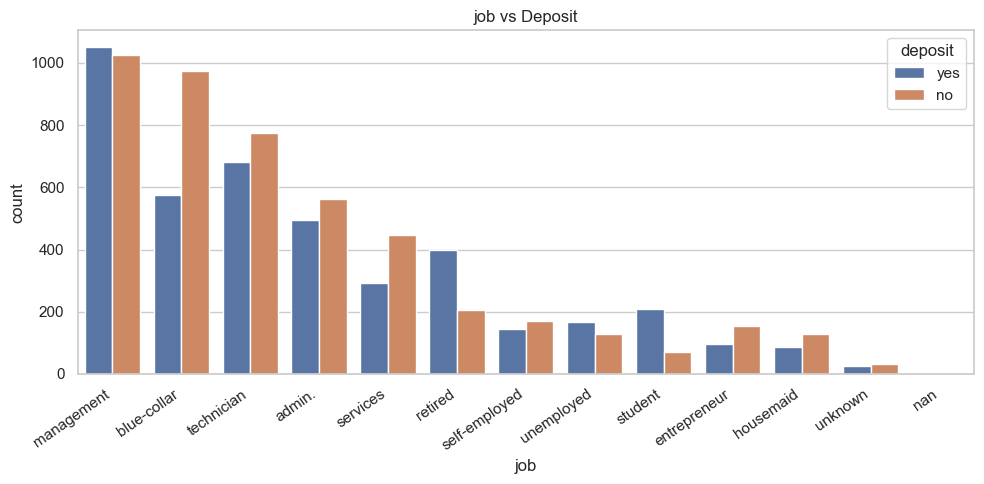

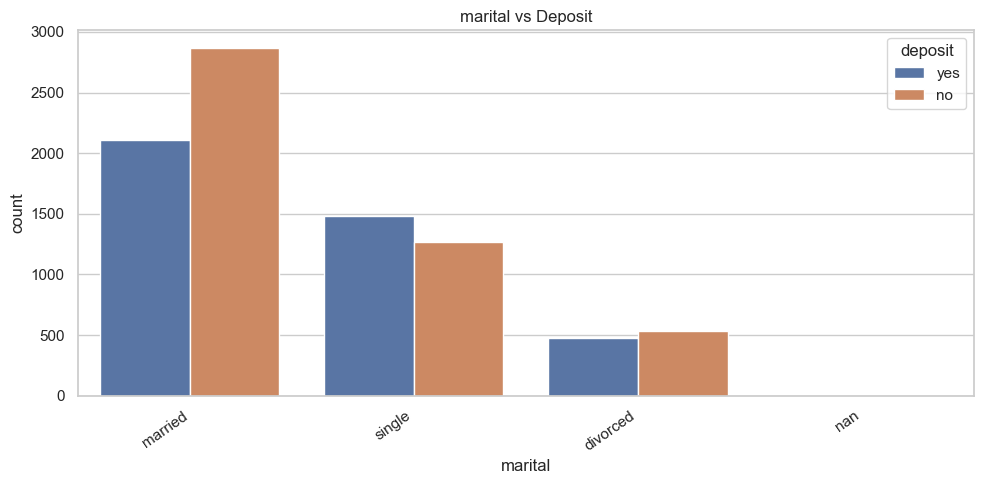

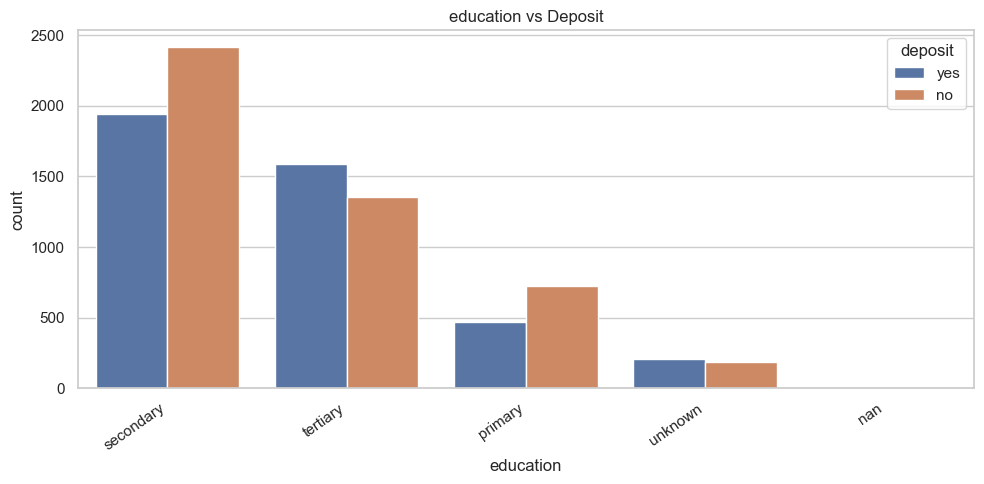

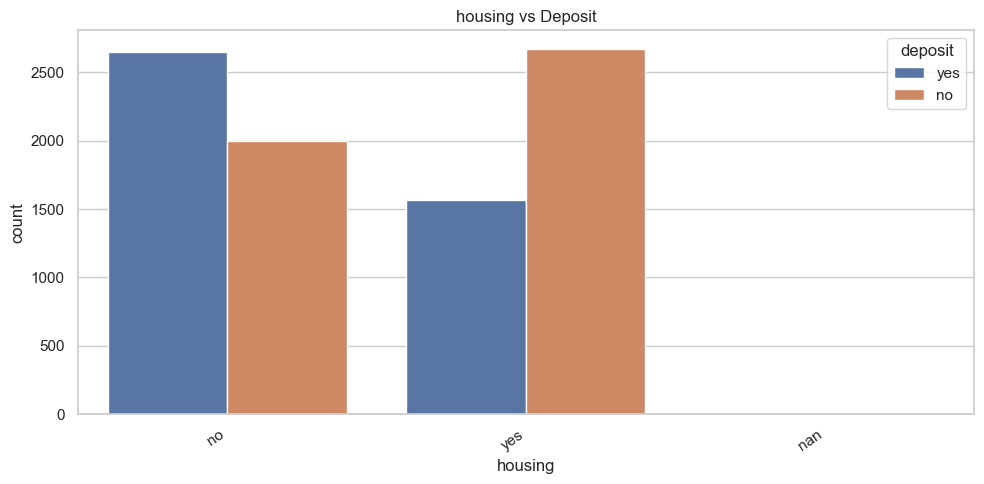

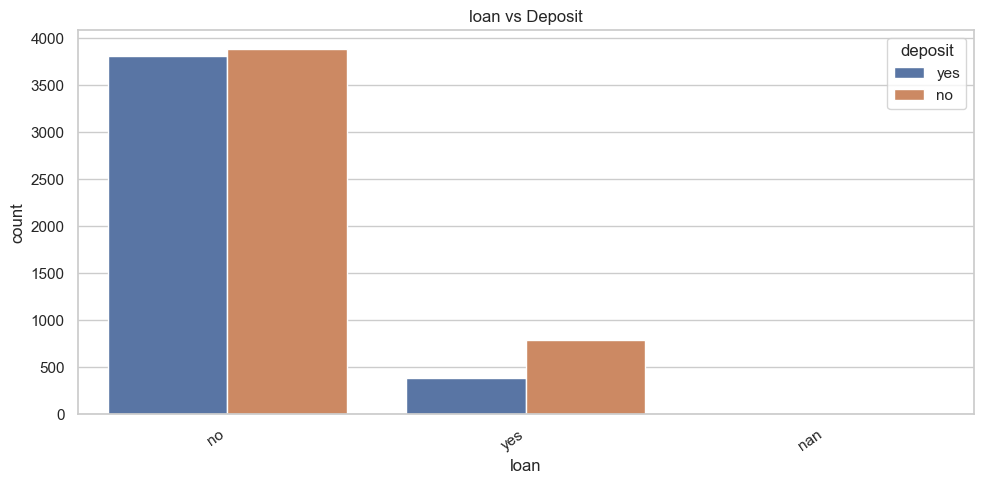

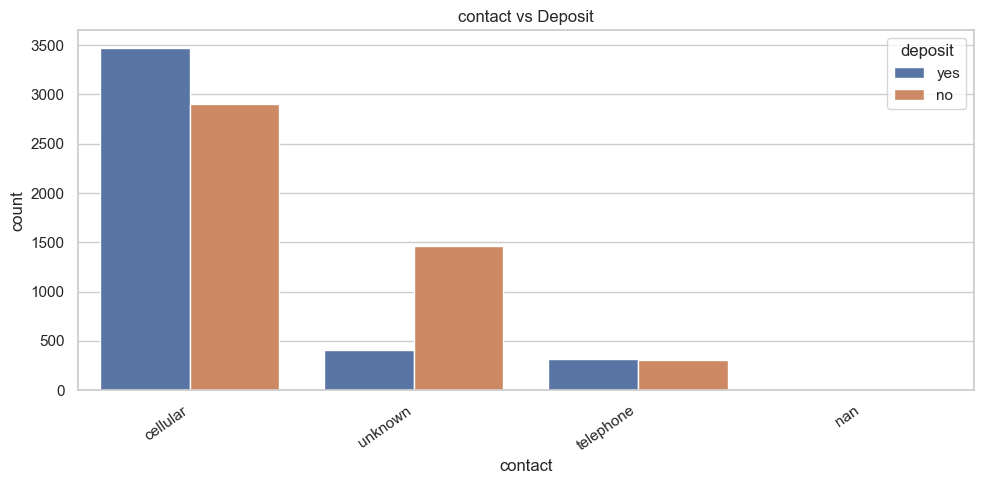

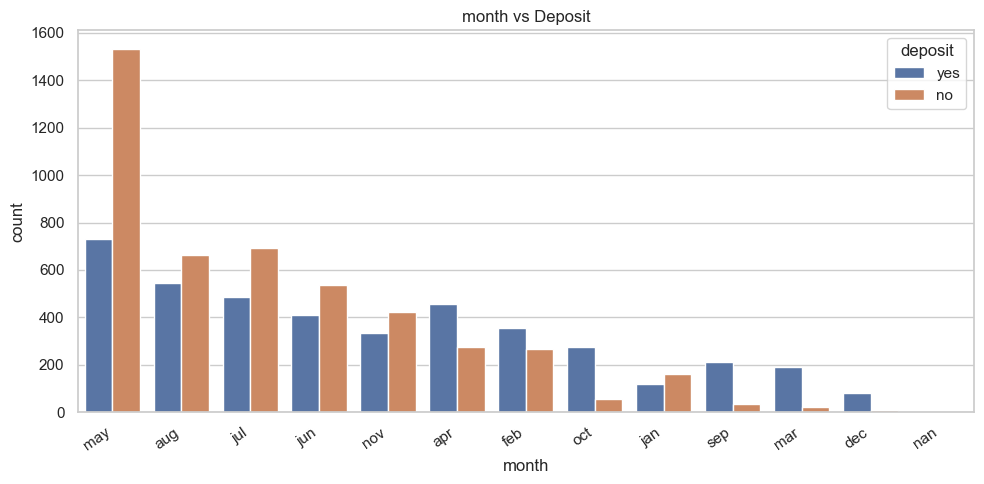

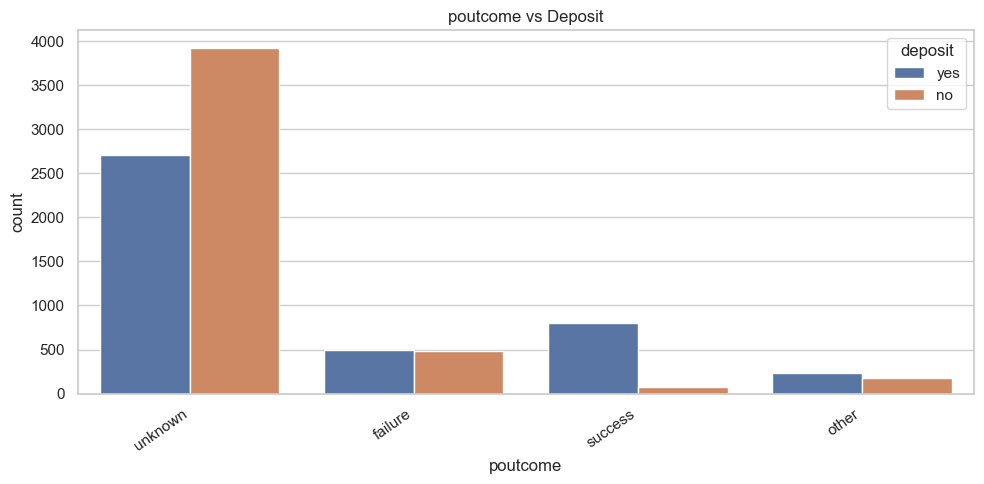

In [8]:
categorical_for_eda = [
    "job", "marital", "education", "housing",
    "loan", "contact", "month", "poutcome"
]

for col in categorical_for_eda:
    plt.figure(figsize=(10,5))
    order = df[col].value_counts(dropna=False).index
    sns.countplot(data=df, x=col, hue="deposit", order=order)
    plt.title(f"{col} vs Deposit")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


## 7. Data Analysis — Subscription Rate


In [9]:
def subscription_rate(data, column):
    return (
        data.groupby(column)["deposit"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
        .to_frame("subscription_rate_%")
    )

for col in categorical_for_eda:
    print(f"===== {col} =====")
    display(subscription_rate(df, col))

df["deposit_binary"] = (df["deposit"] == "yes").astype(int)
display(df.groupby("deposit")[numeric_cols].mean().T.round(2))
df.drop(columns="deposit_binary", inplace=True)


===== job =====


,subscription_rate_%
job,
student,74.91
retired,65.95
unemployed,56.80
management,50.65
admin.,46.88
technician,46.74
self-employed,45.54
unknown,43.86
housemaid,40.47


===== marital =====


,subscription_rate_%
marital,
single,53.91
divorced,47.04
married,42.39


===== education =====


...

===== month =====


,subscription_rate_%
month,
mar,89.30
dec,89.25
sep,86.23
oct,83.64
apr,62.40
feb,57.10
aug,45.03
nov,44.39
jun,43.34


===== poutcome =====


,subscription_rate_%
poutcome,
success,91.02
other,56.14
failure,50.15
unknown,40.81


deposit,no,yes
age,40.96,41.58
balance,1302.76,1801.94
day,16.11,15.21
duration,224.12,540.70
campaign,2.84,2.15
pdays,36.14,71.09
previous,0.54,1.16


## 8. Correlation Analysis


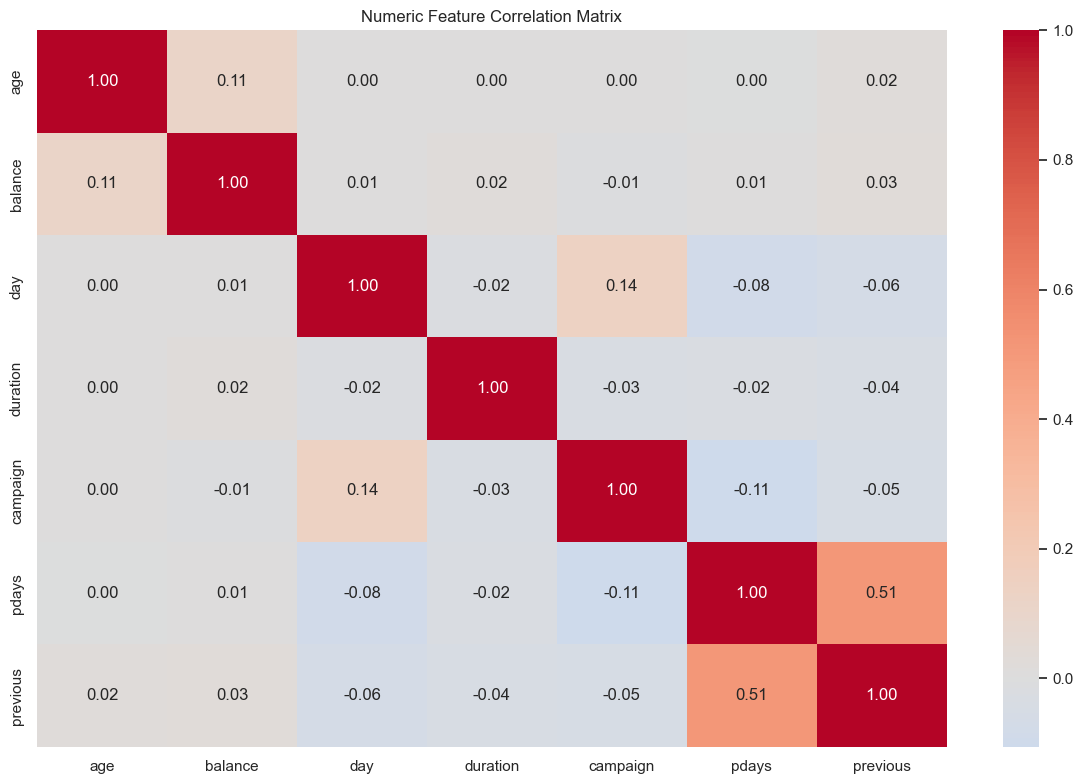

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 9. Train/Test Split


In [11]:
X = df.drop(columns=["deposit"])
y = (df["deposit"] == "yes").astype(int)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))


(7122, 16) (1781, 16)
deposit
0    0.524853
1    0.475147
Name: proportion, dtype: float64


## 10. Preprocessing Pipeline


In [12]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 11. Classification Models


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(probability=True, random_state=1),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=1, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, random_state=1, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=1, n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        verbose=False, random_seed=1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        random_state=1, verbosity=-1, n_jobs=-1
    )
}


## 12. Train + Evaluate All Models


  0%|                                                                                           | 0/13 [00:00<?, ?it/s]


Logistic Regression

Confusion Matrix:
 [[795 140]
 [187 659]]


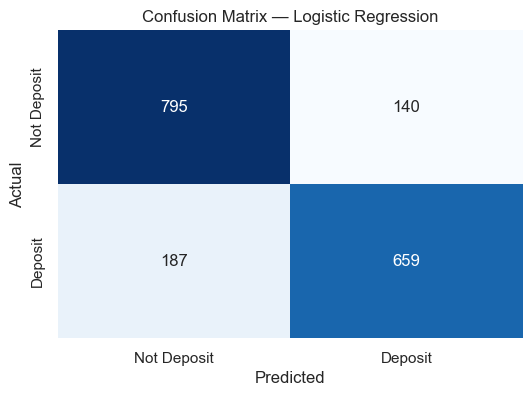

              precision    recall  f1-score   support

 Not Deposit       0.81      0.85      0.83       935
     Deposit       0.82      0.78      0.80       846

    accuracy                           0.82      1781
   macro avg       0.82      0.81      0.82      1781
weighted avg       0.82      0.82      0.82      1781



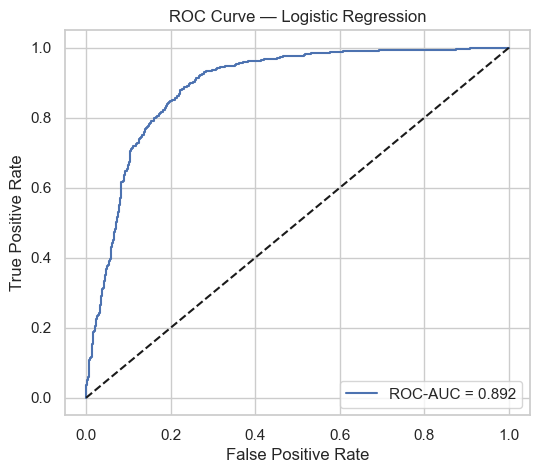

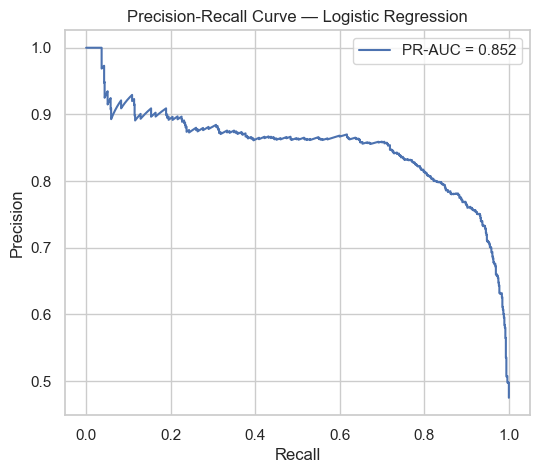

  8%|██████▍                                                                            | 1/13 [00:00<00:10,  1.20it/s]


KNN

Confusion Matrix:
 [[740 195]
 [306 540]]


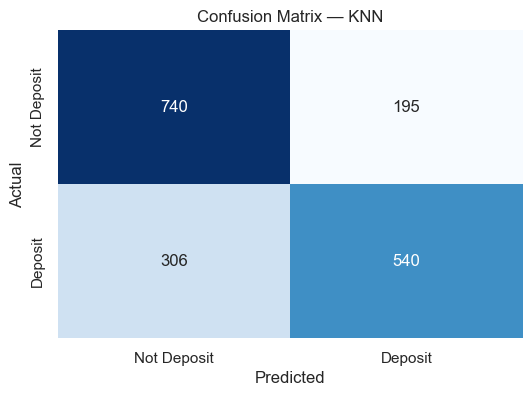

              precision    recall  f1-score   support

 Not Deposit       0.71      0.79      0.75       935
     Deposit       0.73      0.64      0.68       846

    accuracy                           0.72      1781
   macro avg       0.72      0.71      0.72      1781
weighted avg       0.72      0.72      0.72      1781



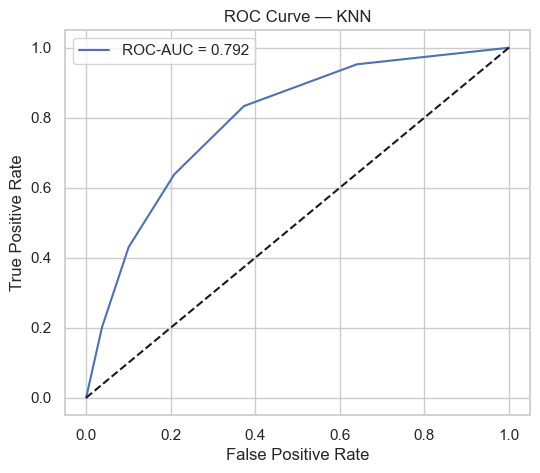

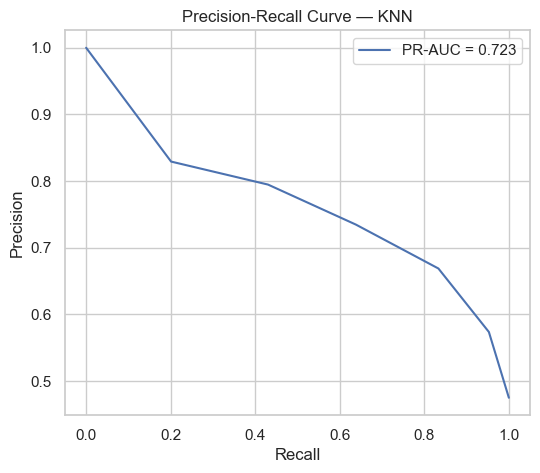

 15%|████████████▊                                                                      | 2/13 [00:03<00:22,  2.08s/it]


SVC

Confusion Matrix:
 [[787 148]
 [162 684]]


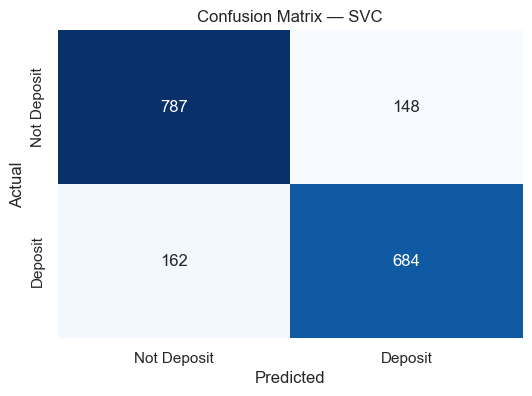

              precision    recall  f1-score   support

 Not Deposit       0.83      0.84      0.84       935
     Deposit       0.82      0.81      0.82       846

    accuracy                           0.83      1781
   macro avg       0.83      0.83      0.83      1781
weighted avg       0.83      0.83      0.83      1781



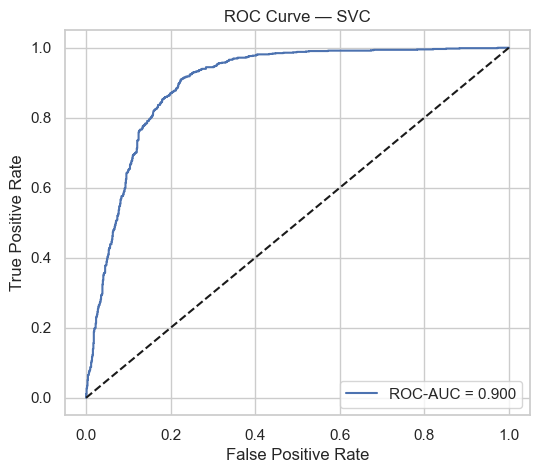

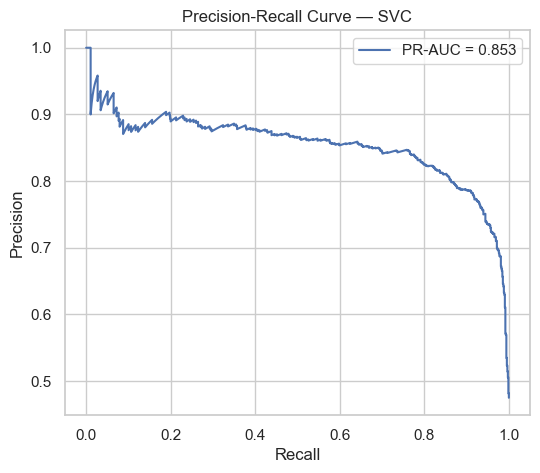

 23%|███████████████████▏                                                               | 3/13 [00:45<03:23, 20.34s/it]


Decision Tree

Confusion Matrix:
 [[734 201]
 [190 656]]


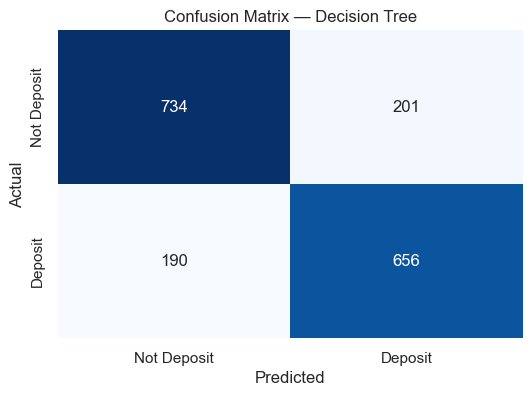

              precision    recall  f1-score   support

 Not Deposit       0.79      0.79      0.79       935
     Deposit       0.77      0.78      0.77       846

    accuracy                           0.78      1781
   macro avg       0.78      0.78      0.78      1781
weighted avg       0.78      0.78      0.78      1781



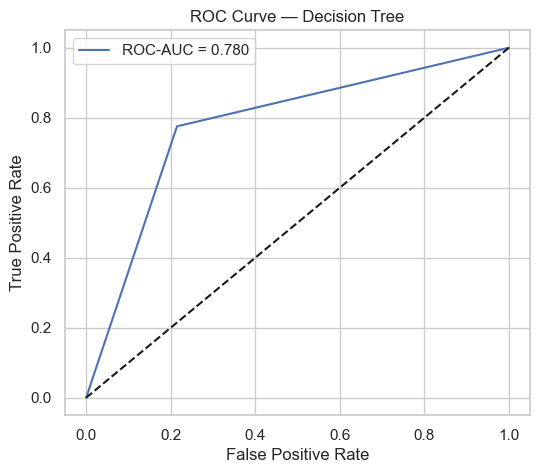

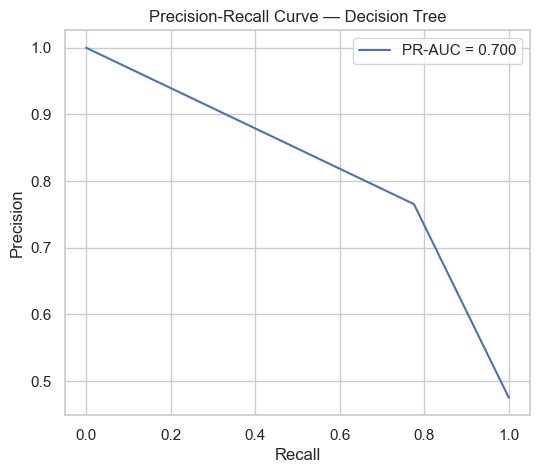

 31%|█████████████████████████▌                                                         | 4/13 [00:46<01:53, 12.59s/it]


Naive Bayes

Confusion Matrix:
 [[788 147]
 [374 472]]


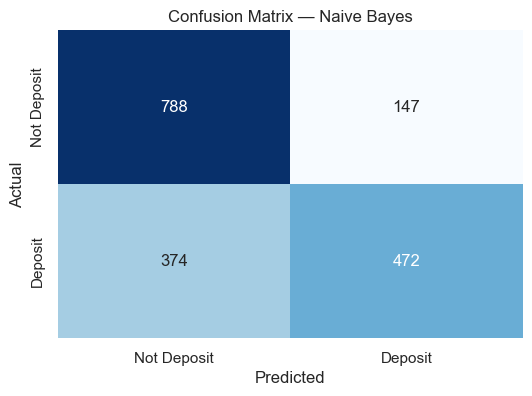

              precision    recall  f1-score   support

 Not Deposit       0.68      0.84      0.75       935
     Deposit       0.76      0.56      0.64       846

    accuracy                           0.71      1781
   macro avg       0.72      0.70      0.70      1781
weighted avg       0.72      0.71      0.70      1781



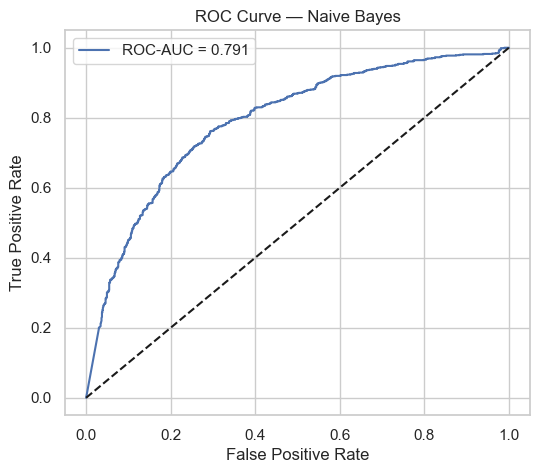

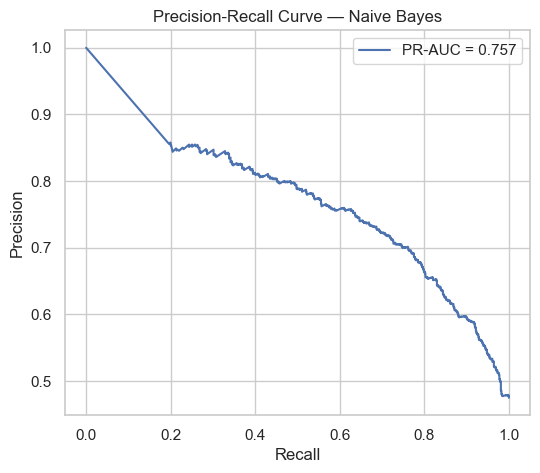

 38%|███████████████████████████████▉                                                   | 5/13 [00:47<01:06,  8.25s/it]


Random Forest

Confusion Matrix:
 [[765 170]
 [ 98 748]]


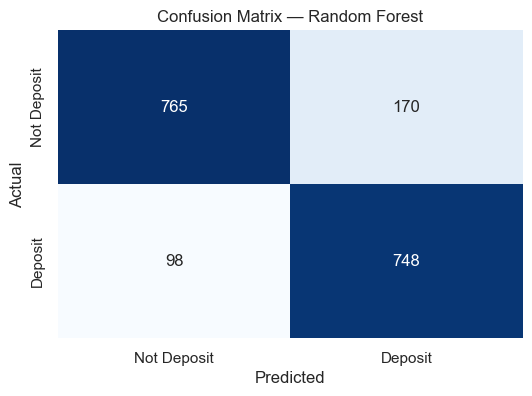

              precision    recall  f1-score   support

 Not Deposit       0.89      0.82      0.85       935
     Deposit       0.81      0.88      0.85       846

    accuracy                           0.85      1781
   macro avg       0.85      0.85      0.85      1781
weighted avg       0.85      0.85      0.85      1781



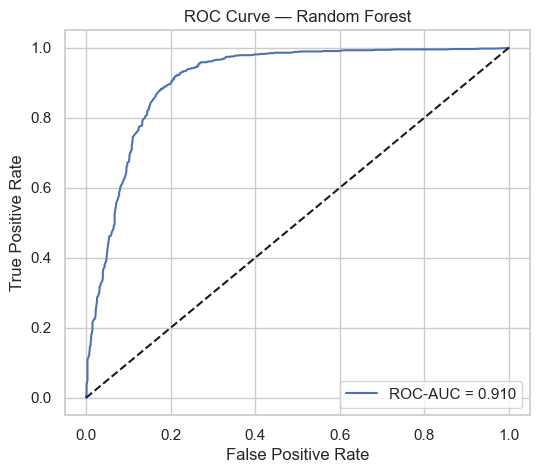

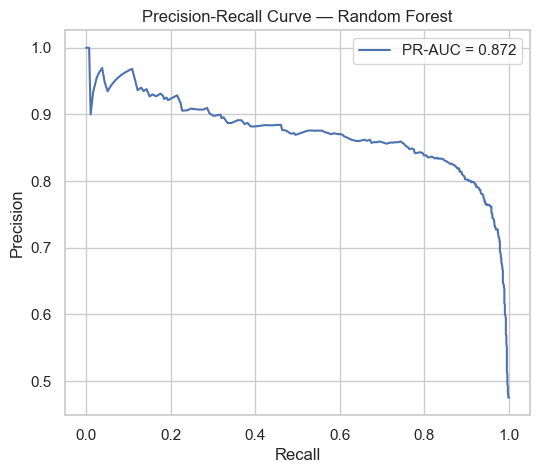

 46%|██████████████████████████████████████▎                                            | 6/13 [00:48<00:42,  6.05s/it]


Extra Trees

Confusion Matrix:
 [[764 171]
 [136 710]]


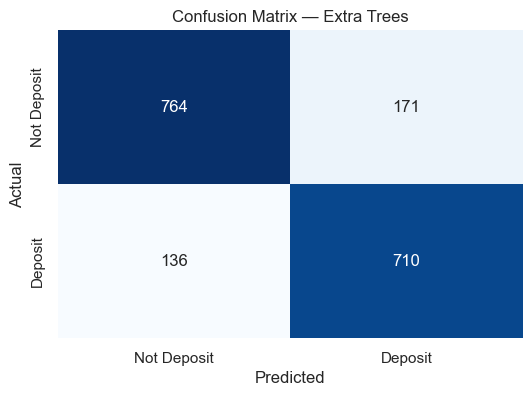

              precision    recall  f1-score   support

 Not Deposit       0.85      0.82      0.83       935
     Deposit       0.81      0.84      0.82       846

    accuracy                           0.83      1781
   macro avg       0.83      0.83      0.83      1781
weighted avg       0.83      0.83      0.83      1781



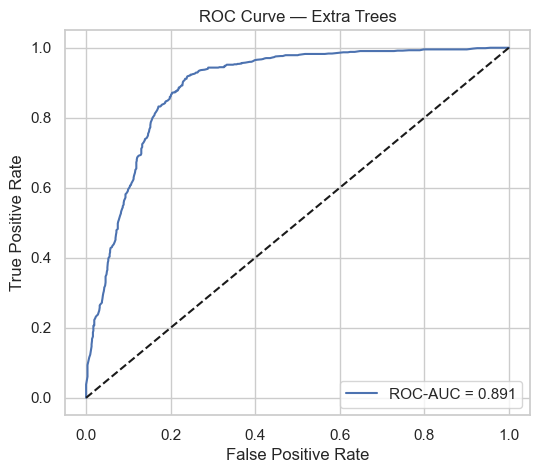

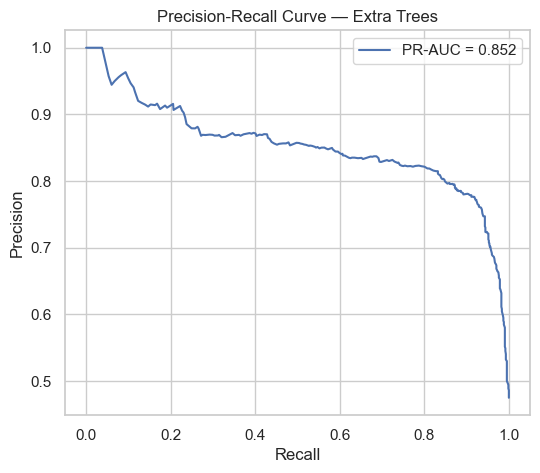

 54%|████████████████████████████████████████████▋                                      | 7/13 [00:50<00:27,  4.63s/it]


AdaBoost

Confusion Matrix:
 [[776 159]
 [182 664]]


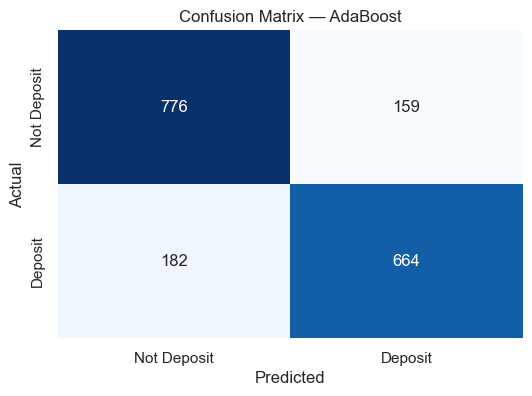

              precision    recall  f1-score   support

 Not Deposit       0.81      0.83      0.82       935
     Deposit       0.81      0.78      0.80       846

    accuracy                           0.81      1781
   macro avg       0.81      0.81      0.81      1781
weighted avg       0.81      0.81      0.81      1781



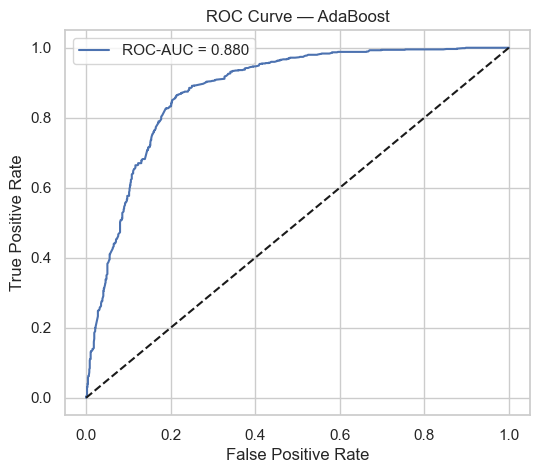

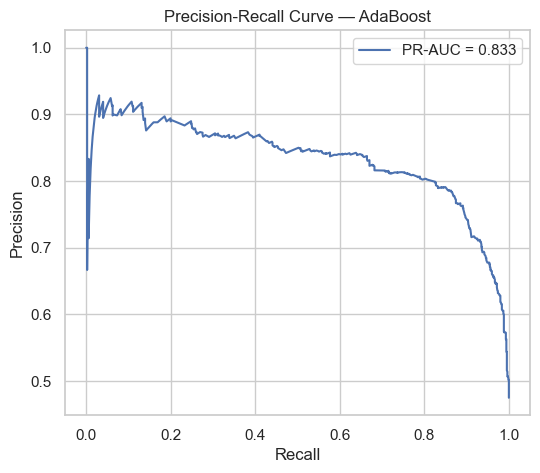

 62%|███████████████████████████████████████████████████                                | 8/13 [00:51<00:17,  3.48s/it]


Gradient Boosting

Confusion Matrix:
 [[770 165]
 [111 735]]


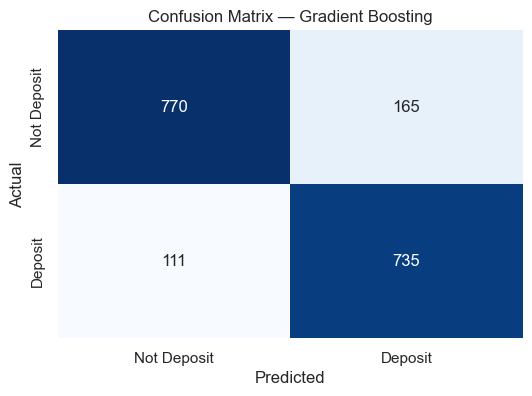

              precision    recall  f1-score   support

 Not Deposit       0.87      0.82      0.85       935
     Deposit       0.82      0.87      0.84       846

    accuracy                           0.85      1781
   macro avg       0.85      0.85      0.84      1781
weighted avg       0.85      0.85      0.85      1781



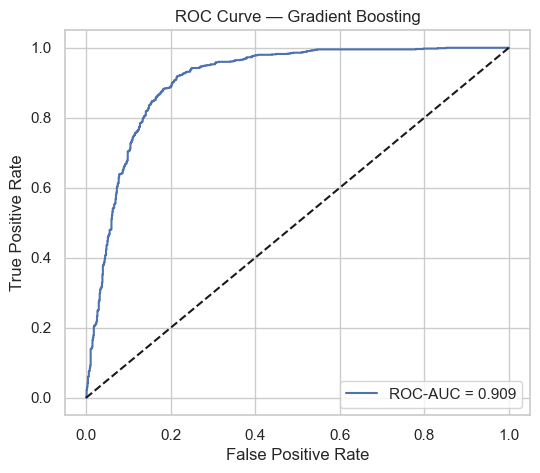

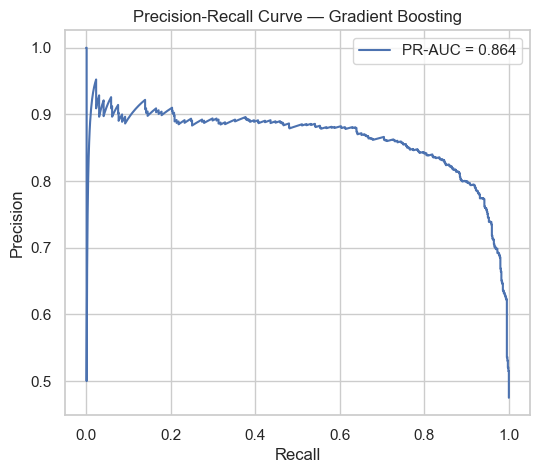

 69%|█████████████████████████████████████████████████████████▍                         | 9/13 [00:53<00:11,  2.97s/it]


Hist Gradient Boosting

Confusion Matrix:
 [[772 163]
 [ 92 754]]


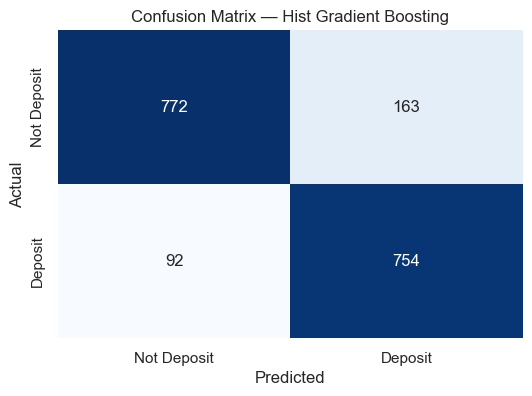

              precision    recall  f1-score   support

 Not Deposit       0.89      0.83      0.86       935
     Deposit       0.82      0.89      0.86       846

    accuracy                           0.86      1781
   macro avg       0.86      0.86      0.86      1781
weighted avg       0.86      0.86      0.86      1781



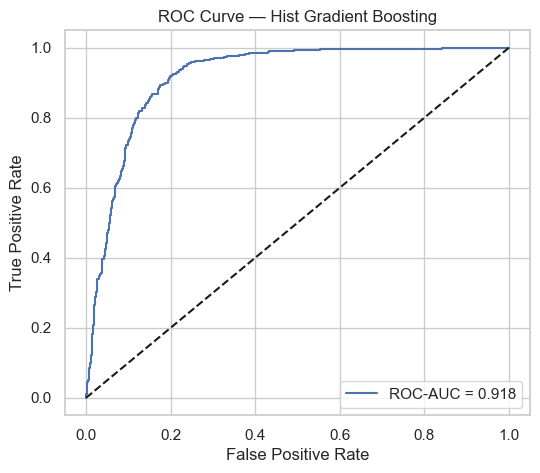

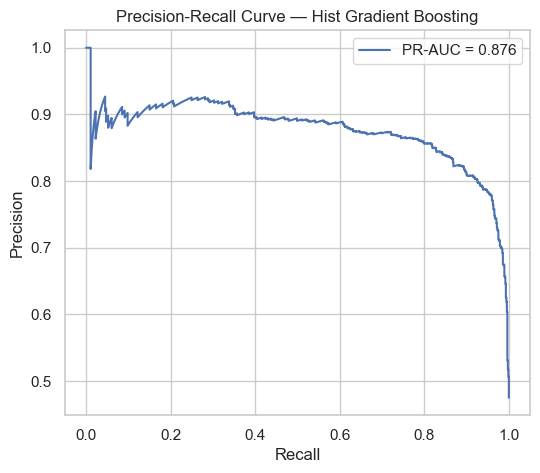

 77%|███████████████████████████████████████████████████████████████                   | 10/13 [00:54<00:07,  2.40s/it]


XGBoost

Confusion Matrix:
 [[773 162]
 [ 98 748]]


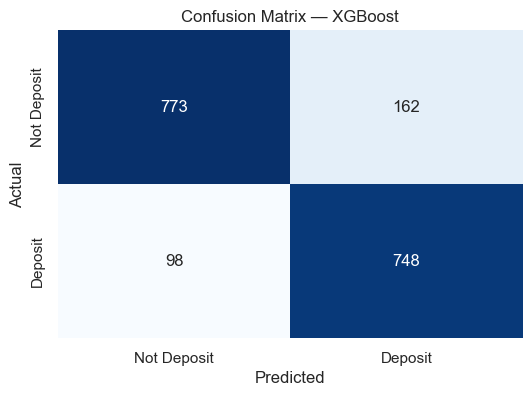

              precision    recall  f1-score   support

 Not Deposit       0.89      0.83      0.86       935
     Deposit       0.82      0.88      0.85       846

    accuracy                           0.85      1781
   macro avg       0.85      0.86      0.85      1781
weighted avg       0.86      0.85      0.85      1781



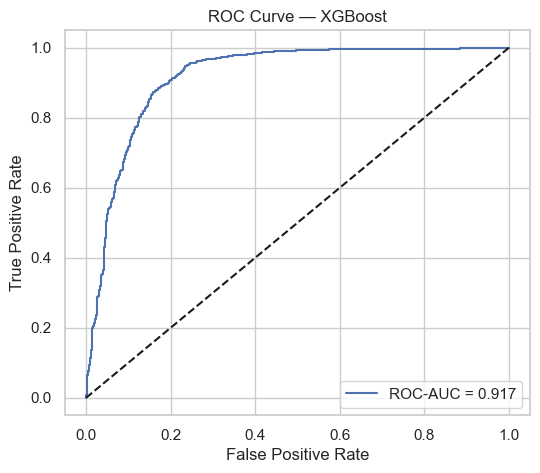

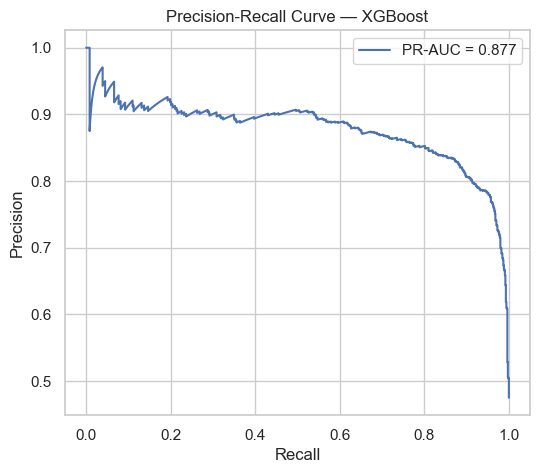

 85%|█████████████████████████████████████████████████████████████████████▍            | 11/13 [00:55<00:03,  1.99s/it]


CatBoost

Confusion Matrix:
 [[774 161]
 [ 95 751]]


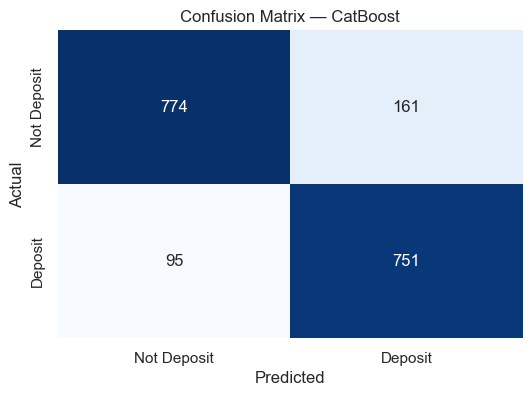

              precision    recall  f1-score   support

 Not Deposit       0.89      0.83      0.86       935
     Deposit       0.82      0.89      0.85       846

    accuracy                           0.86      1781
   macro avg       0.86      0.86      0.86      1781
weighted avg       0.86      0.86      0.86      1781



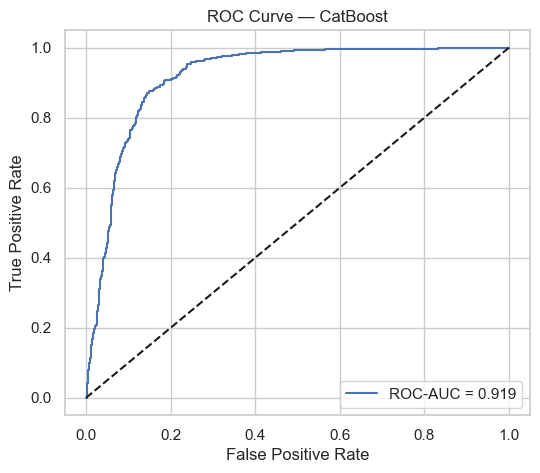

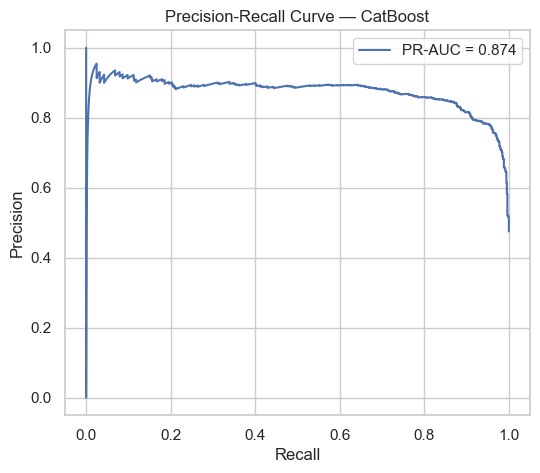

 92%|███████████████████████████████████████████████████████████████████████████▋      | 12/13 [00:58<00:02,  2.13s/it]


LightGBM

Confusion Matrix:
 [[767 168]
 [ 95 751]]


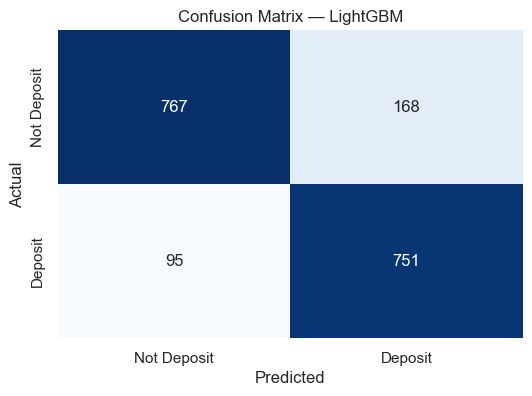

              precision    recall  f1-score   support

 Not Deposit       0.89      0.82      0.85       935
     Deposit       0.82      0.89      0.85       846

    accuracy                           0.85      1781
   macro avg       0.85      0.85      0.85      1781
weighted avg       0.86      0.85      0.85      1781



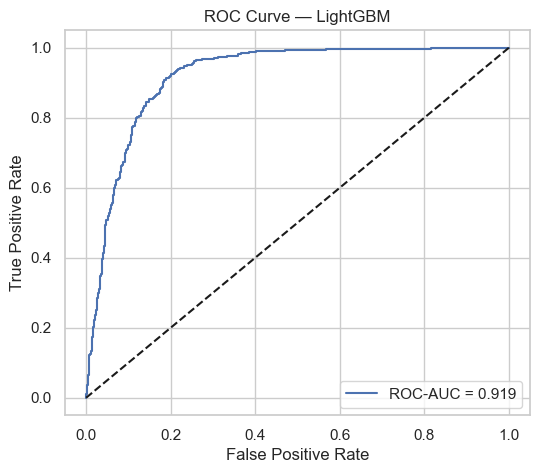

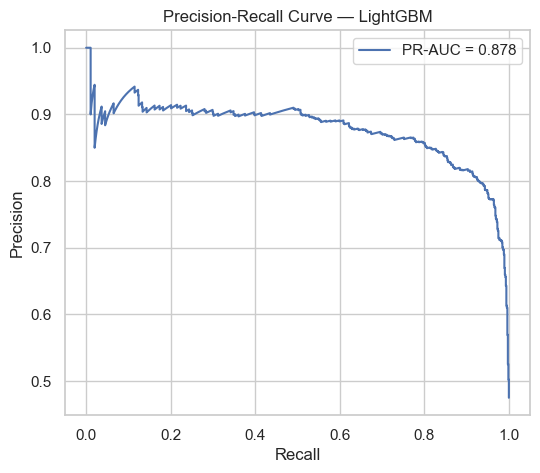

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:59<00:00,  4.56s/it]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy,ROC-AUC,PR AUC
Hist Gradient Boosting,0.9187,0.8568,0.8886,0.8222,0.9477,0.8913,0.9172,0.8554,0.9201,0.8585,0.9185,0.8760
CatBoost,0.8978,0.8563,0.8720,0.8235,0.9199,0.8877,0.8953,0.8544,0.8988,0.8578,0.9193,0.8743
XGBoost,0.9083,0.8540,0.8811,0.8220,0.9329,0.8842,0.9063,0.8519,0.9095,0.8554,0.9173,0.8774
LightGBM,0.9429,0.8523,0.9204,0.8172,0.9631,0.8877,0.9412,0.8510,0.9438,0.8540,0.9192,0.8776
Random Forest,1.0000,0.8495,1.0000,0.8148,1.0000,0.8842,1.0000,0.8481,1.0000,0.8512,0.9095,0.8719
Gradient Boosting,0.8585,0.8450,0.8396,0.8167,0.8679,0.8688,0.8535,0.8419,0.8589,0.8462,0.9091,0.8640
Extra Trees,1.0000,0.8276,1.0000,0.8059,1.0000,0.8392,1.0000,0.8222,1.0000,0.8282,0.8909,0.8516
SVC,0.8596,0.8259,0.8661,0.8221,0.8333,0.8085,0.8494,0.8153,0.8583,0.8251,0.8996,0.8534
Logistic Regression,0.8266,0.8164,0.8374,0.8248,0.7881,0.7790,0.8120,0.8012,0.8248,0.8146,0.8925,0.8518
AdaBoost,0.8124,0.8085,0.8153,0.8068,0.7825,0.7849,0.7986,0.7957,0.8110,0.8074,0.8801,0.8330


In [14]:
results = {}
fitted_models = {}

for name, model in tqdm(models.items()):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    y_pred_prob = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, test_pred)
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Not Deposit", "Deposit"],
        yticklabels=["Not Deposit", "Deposit"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    print(classification_report(
        y_test, test_pred,
        target_names=["Not Deposit", "Deposit"],
        zero_division=0
    ))

    roc_auc = roc_auc_score(y_test, y_pred_prob)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend()
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {name}")
    plt.legend()
    plt.show()

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred, zero_division=0),
        "Test Precision": precision_score(y_test, test_pred, zero_division=0),
        "Train Recall": recall_score(y_train, train_pred, zero_division=0),
        "Test Recall": recall_score(y_test, test_pred, zero_division=0),
        "Train F1 Score": f1_score(y_train, train_pred, zero_division=0),
        "Test F1 Score": f1_score(y_test, test_pred, zero_division=0),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "ROC-AUC": roc_auc,
        "PR AUC": pr_auc
    }

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).T.sort_values("Test F1 Score", ascending=False)
display(results_df.round(4))


## 13. Model Comparison


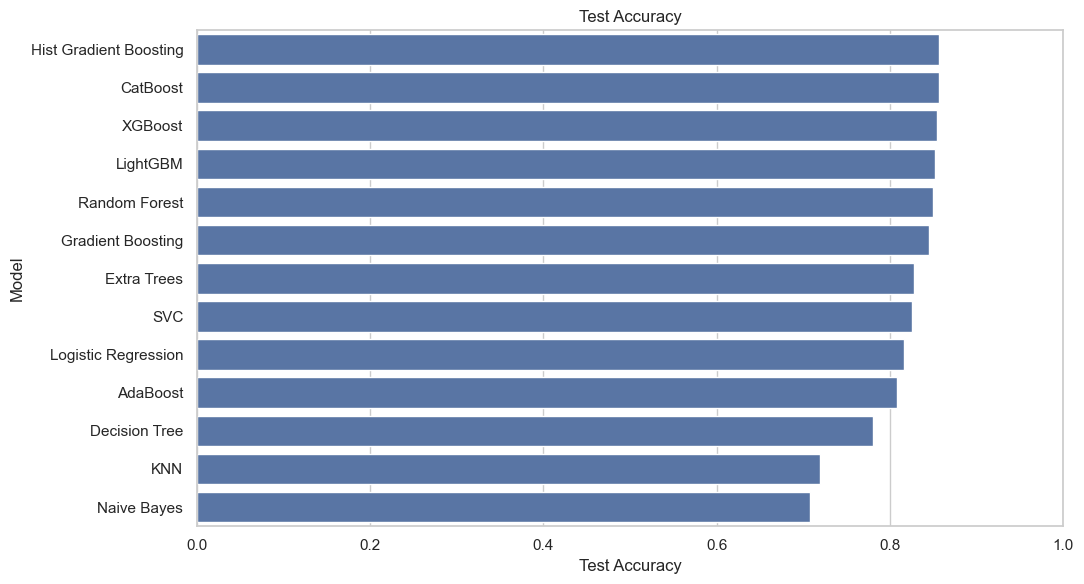

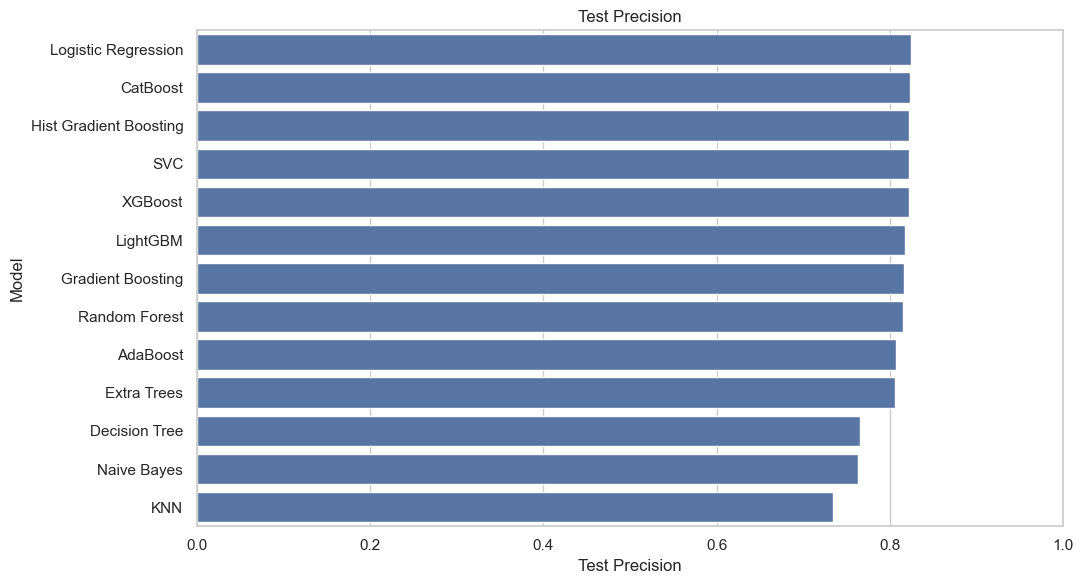

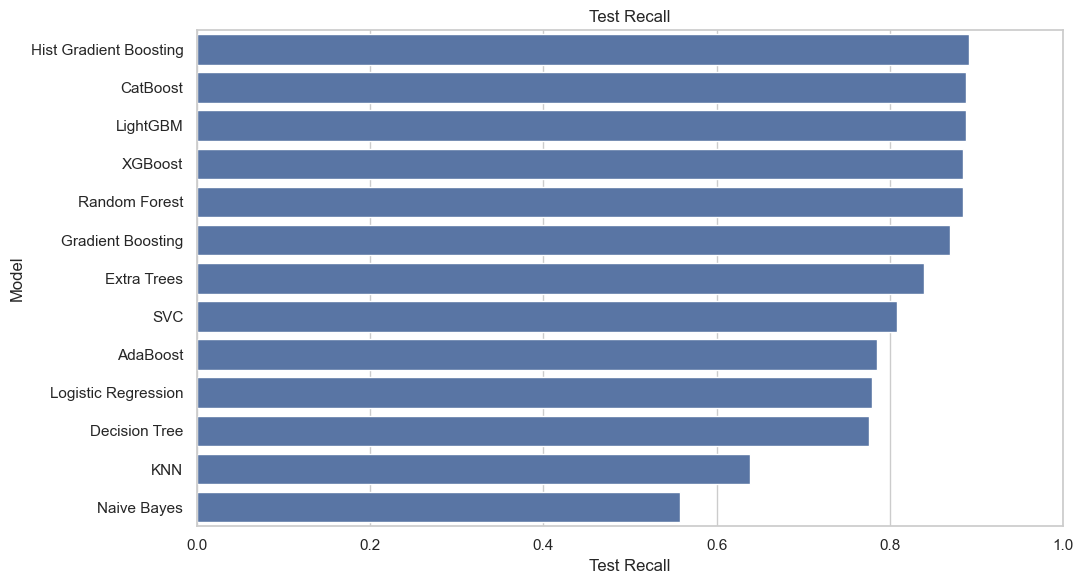

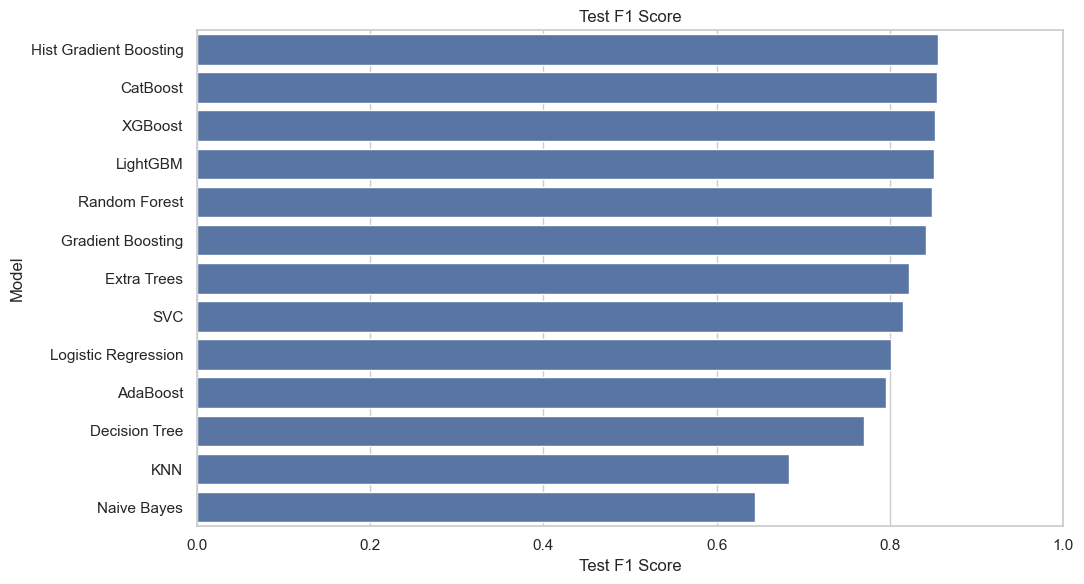

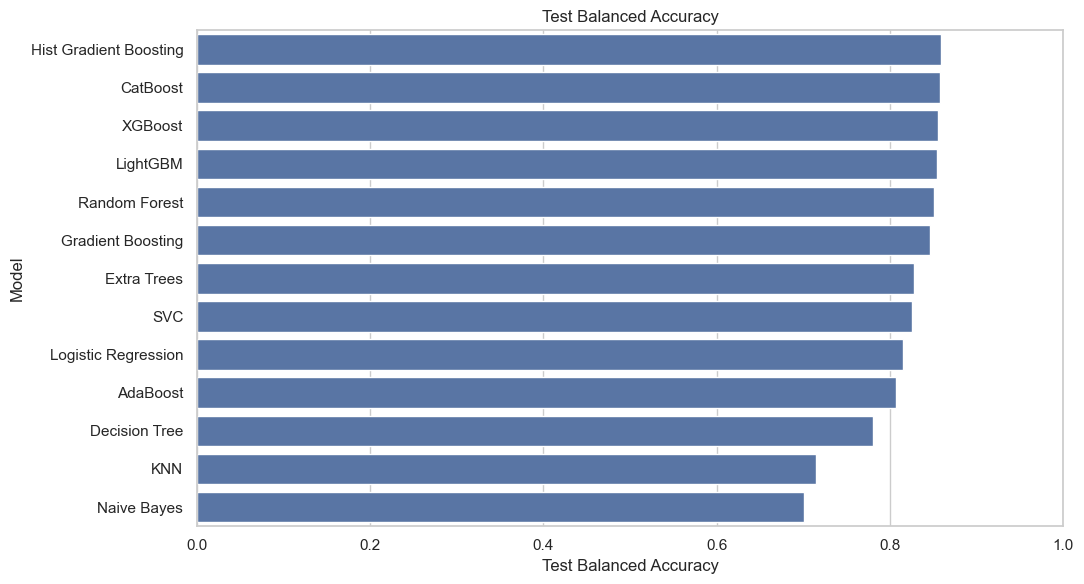

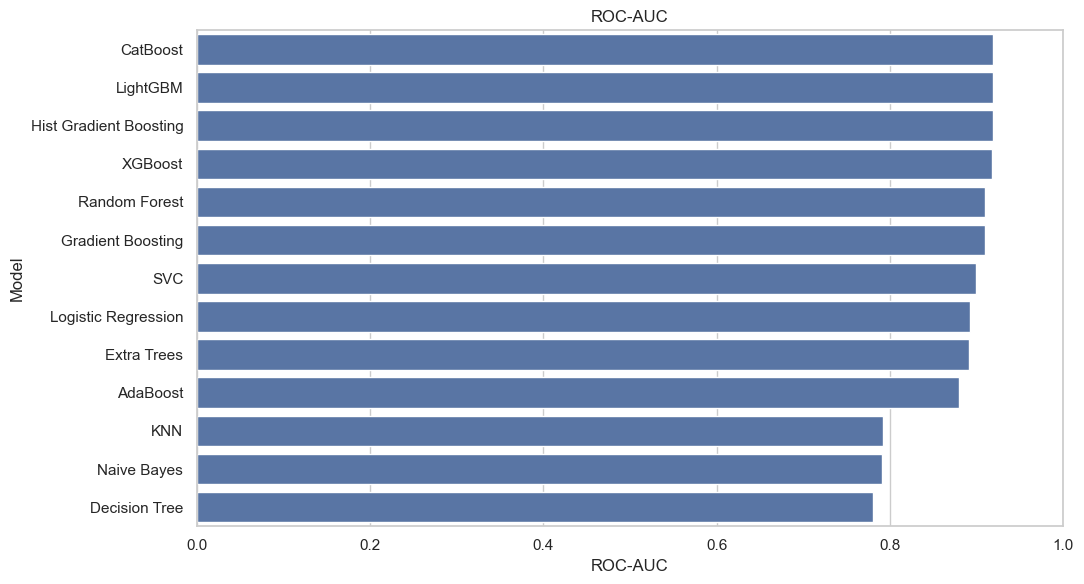

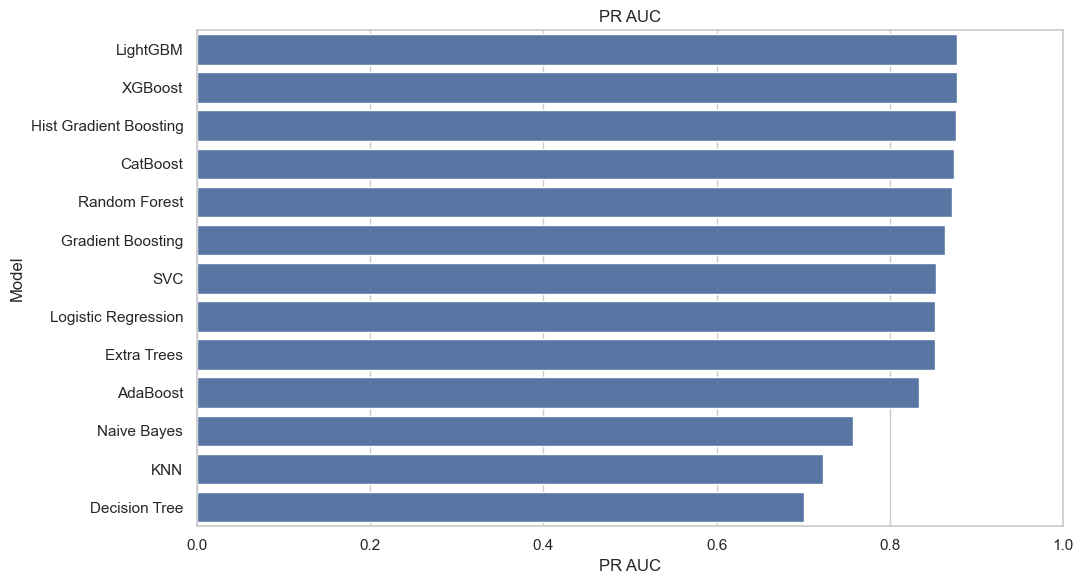

In [15]:
for metric in [
    "Test Accuracy", "Test Precision", "Test Recall",
    "Test F1 Score", "Test Balanced Accuracy", "ROC-AUC", "PR AUC"
]:
    plt.figure(figsize=(11,6))
    order = results_df[metric].sort_values(ascending=False).index
    sns.barplot(x=results_df.loc[order, metric].values, y=order)
    plt.title(metric)
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()


## 14. GridSearchCV

Grid search is run on the training set only using 5-fold StratifiedKFold. The test set remains untouched until final evaluation.


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, random_state=1),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=1, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__max_features": ["sqrt", "log2"]
        }
    ),

    "Extra Trees": (
        ExtraTreesClassifier(random_state=1, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__max_features": ["sqrt", "log2"]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=1),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 5]
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=1, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    ),

    "LightGBM": (
        LGBMClassifier(random_state=1, verbosity=-1, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__num_leaves": [15, 31, 63],
            "model__max_depth": [-1, 5, 10]
        }
    )
}


In [17]:
grid_results = {}
best_estimators = {}

for name, (model, param_grid) in grid_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    print("\n" + "="*80)
    print("Grid Search:", name)
    print("="*80)

    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    pred = grid.best_estimator_.predict(X_test)
    prob = grid.best_estimator_.predict_proba(X_test)[:,1]

    grid_results[name] = {
        "Best CV F1": grid.best_score_,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred, zero_division=0),
        "Test Recall": recall_score(y_test, pred, zero_division=0),
        "Test F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Best Params": grid.best_params_
    }

    print("Best CV F1:", round(grid.best_score_, 4))
    print("Best parameters:", grid.best_params_)

grid_results_df = pd.DataFrame(grid_results).T.sort_values("Test F1", ascending=False)
display(grid_results_df)



Grid Search: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best CV F1: 0.8103
Best parameters: {'model__C': 10, 'model__solver': 'lbfgs'}

Grid Search: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV F1: 0.8527
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 400}

Grid Search: Extra Trees
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV F1: 0.8248
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 400}

Grid Search: Gradient Boosting
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CV F1: 0.8581
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Grid Search: XGBoost
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best CV F1: 0.8583
Best parameters: {'model__cols

,Best CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,ROC-AUC,PR-AUC,Best Params
LightGBM,0.859508,0.857383,0.821739,0.893617,0.856172,0.919739,0.878987,"{'model__learning_rate': 0.05, 'model__max_dep..."
Random Forest,0.852722,0.850646,0.813175,0.890071,0.849887,0.91,0.874734,"{'model__max_depth': None, 'model__max_feature..."
Gradient Boosting,0.858134,0.851769,0.824053,0.874704,0.848624,0.914951,0.869728,"{'model__learning_rate': 0.1, 'model__max_dept..."
XGBoost,0.858332,0.8484,0.815098,0.880615,0.846591,0.917141,0.880744,"{'model__colsample_bytree': 1.0, 'model__learn..."
Extra Trees,0.824834,0.832117,0.80904,0.846336,0.827267,0.893817,0.852742,"{'model__max_depth': None, 'model__max_feature..."
Logistic Regression,0.810261,0.819203,0.818735,0.795508,0.806954,0.893903,0.852526,"{'model__C': 10, 'model__solver': 'lbfgs'}"


## 15. Final Tuned Model


Best tuned model: LightGBM

              precision    recall  f1-score   support

 Not Deposit       0.90      0.82      0.86       935
     Deposit       0.82      0.89      0.86       846

    accuracy                           0.86      1781
   macro avg       0.86      0.86      0.86      1781
weighted avg       0.86      0.86      0.86      1781



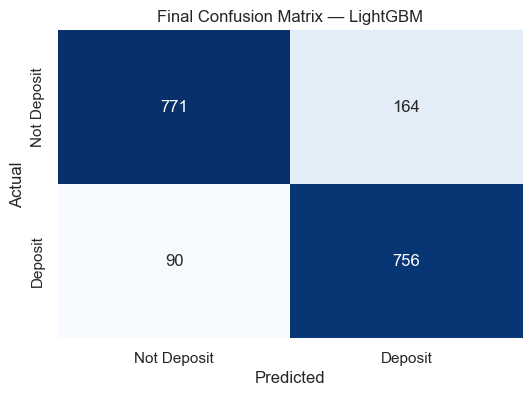

Accuracy: 0.8574
Precision: 0.8217
Recall: 0.8936
F1: 0.8562
Balanced Accuracy: 0.8591
ROC-AUC: 0.9197
PR-AUC: 0.879


In [18]:
best_model_name = grid_results_df["Test F1"].idxmax()
best_model = best_estimators[best_model_name]

final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)[:,1]

print("Best tuned model:", best_model_name)
print()
print(classification_report(
    y_test, final_pred,
    target_names=["Not Deposit", "Deposit"],
    zero_division=0
))

final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    final_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Not Deposit", "Deposit"],
    yticklabels=["Not Deposit", "Deposit"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final Confusion Matrix — {best_model_name}")
plt.show()

final_roc_auc = roc_auc_score(y_test, final_prob)
final_pr_auc = average_precision_score(y_test, final_prob)

print("Accuracy:", round(accuracy_score(y_test, final_pred), 4))
print("Precision:", round(precision_score(y_test, final_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, final_pred, zero_division=0), 4))
print("F1:", round(f1_score(y_test, final_pred, zero_division=0), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, final_pred), 4))
print("ROC-AUC:", round(final_roc_auc, 4))
print("PR-AUC:", round(final_pr_auc, 4))


## 16. Final ROC / PR Curves


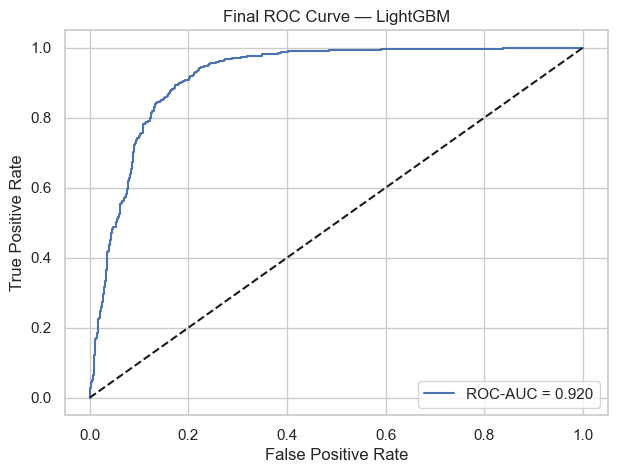

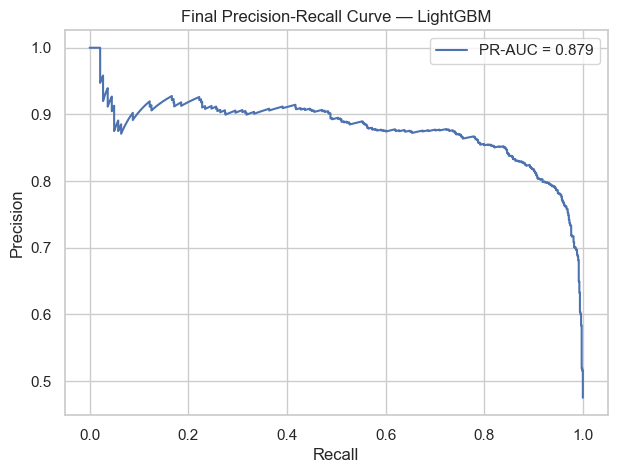

In [19]:
fpr, tpr, _ = roc_curve(y_test, final_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {final_roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Final ROC Curve — {best_model_name}")
plt.legend()
plt.show()

precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_prob)
plt.figure(figsize=(7,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {final_pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Final Precision-Recall Curve — {best_model_name}")
plt.legend()
plt.show()


## 17. Feature Importance / Interpretation


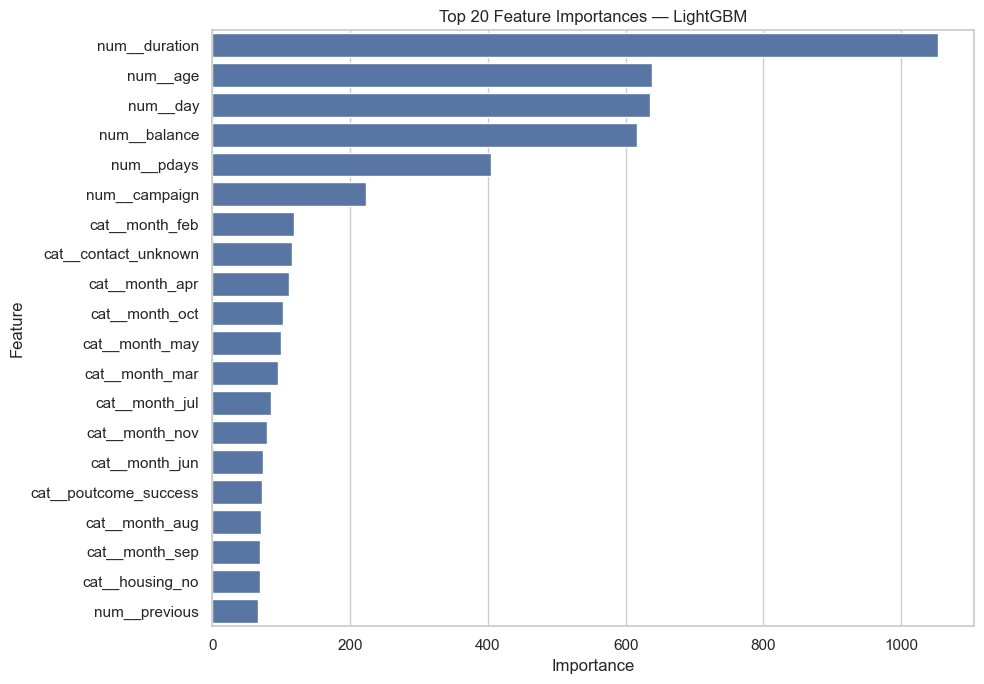

,importance
num__duration,1053
num__age,639
num__day,635
num__balance,617
num__pdays,405
num__campaign,223
cat__month_feb,118
cat__contact_unknown,116
cat__month_apr,112
cat__month_oct,102


In [20]:
model_step = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importance = pd.Series(
        model_step.feature_importances_, index=feature_names
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10,7))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    display(importance.to_frame("importance"))

elif hasattr(model_step, "coef_"):
    importance = pd.Series(
        np.abs(model_step.coef_[0]), index=feature_names
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10,7))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Top 20 Absolute Coefficients — {best_model_name}")
    plt.xlabel("Absolute coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    display(importance.to_frame("absolute_coefficient"))


## 18. Conclusion

This project covers the full ML workflow:

- Cleaning and validation
- Missing-value treatment
- EDA
- Customer/subscription analysis
- Feature preprocessing
- 13 classification models
- Confusion matrices
- Classification reports
- ROC-AUC and PR-AUC
- Model comparison
- GridSearchCV with cross-validation
- Final tuned model
- Feature importance

**Important:** the test set is kept separate from GridSearchCV and is used only for final model evaluation.
